## 円周率の近似

次の 2 つの公式を用いて，円周率 $\pi$ の近似値を計算します．

$$ p_n = 4\sum_{k=0}^{n-1} \frac{(-1)^k}{2k+1} $$

$$ q_n = \left[ \frac{2\sqrt{2}}{9801} \sum_{k=0}^{n-1} \frac{(4k)!(1103+26390k)}{(k!)^4 396^{4k}} \right]^{-1} $$

1. 正の整数 `n` を受け取り，$p_n$ を返す関数 `approx_pi_arctan(n)` を定義しなさい．
2. 正の整数 `n` を受け取り，$q_n$ を返す関数 `approx_pi_ramanujan(n)` を定義しなさい．階乗の計算には `math.factorial()` を用いても良い．
3. $n=1,2,\ldots$ に対してそれぞれの誤差 $|p_n-\pi|$，$|q_n-\pi|$ を計算し，$n$ と誤差の関係をプロットしなさい．ただし，$q_n$ は非常に速く収束するため，$n=1,\ldots,5$ 程度でよい．

In [1]:
import math

def approx_pi_arctan(n: int) -> float:
    return 0

def approx_pi_ramanujan(n: int) -> float:
    return 0

errors_arctan = []
errors_ramanujan = []

assert math.isclose(approx_pi_arctan(10), math.pi)
assert math.isclose(approx_pi_ramanujan(10), math.pi)

AssertionError: 

### 補足：近似公式の由来

$p_n$ は，ライプニッツの公式

$$ \frac{\pi}{4} = 1-\frac{1}{3}+\frac{1}{5}-\frac{1}{7}+\cdots = \sum_{k=0}^{\infty}\frac{(-1)^k}{2k+1} $$

を $n-1$ 項までで打ち切った近似式である．この公式は，$\arctan x$ のマクローリン展開に $x=1$ を代入し，$\arctan 1=\pi/4$ を用いて得られる．

一方，$q_n$ は，ラマヌジャンの公式

$$ \frac{1}{\pi} = \frac{2\sqrt{2}}{9801} \sum_{k=0}^{\infty} \frac{(4k)!(1103+26390k)} {(k!)^4 396^{4k}} $$

を $n-1$ 項までで打ち切った近似式である．ラマヌジャンの公式は非常に収束が速く，少ない項数でも高い精度の近似値が得られる．

<hr> 

## 複素ニュートン法とフラクタル構造の観察

**フラクタル**とは，図形の一部を拡大すると全体と同じような形が繰り返し現れる「自己相似性」を持つ幾何学的な構造のことです．方程式の解を求めるニュートン法を実数から複素数へと拡張すると，初期値がどの解に収束するかを分ける境界領域において，このフラクタル構造（ニュートン・フラクタル）が現れることが知られています．

Python で複素数を定義するには，虚数単位を文字 `j` を用いて表します．例えば，実数 $1$ は `1.0 + 0.0j`，虚数単位 $i$ は `0.0 + 1.0j` と記述します．ニュートン法のプログラムは，初期値として複素数を与えても正常に動作します（例えば，`np.abs()` は引数に複素数を受け取ることができ，この場合は複素平面上での絶対値を返します）．

以下のプログラムは，複素方程式 $z^n - 1 = 0$ に対して，複素平面上の各点からニュートン法を実行し，どの解に収束したかに応じてピクセルを色分けして描画しています．プログラムは「方程式の定義」「数値計算」「収束先分類」「画像生成」の4つの部分に分かれています．授業で扱っていないプログラム（クラスや高度な配列操作等）を多用していますが，詳細な動作原理を理解する必要はありません．

興味があれば，プログラムの最終部で $n$ を変更したり，方程式クラス `UnityRootEquation` を適当に書き換えたりして，好きなニュートンフラクタルを描いてみてください．

Generating Newton fractal for $z^3 - 1 = 0$...


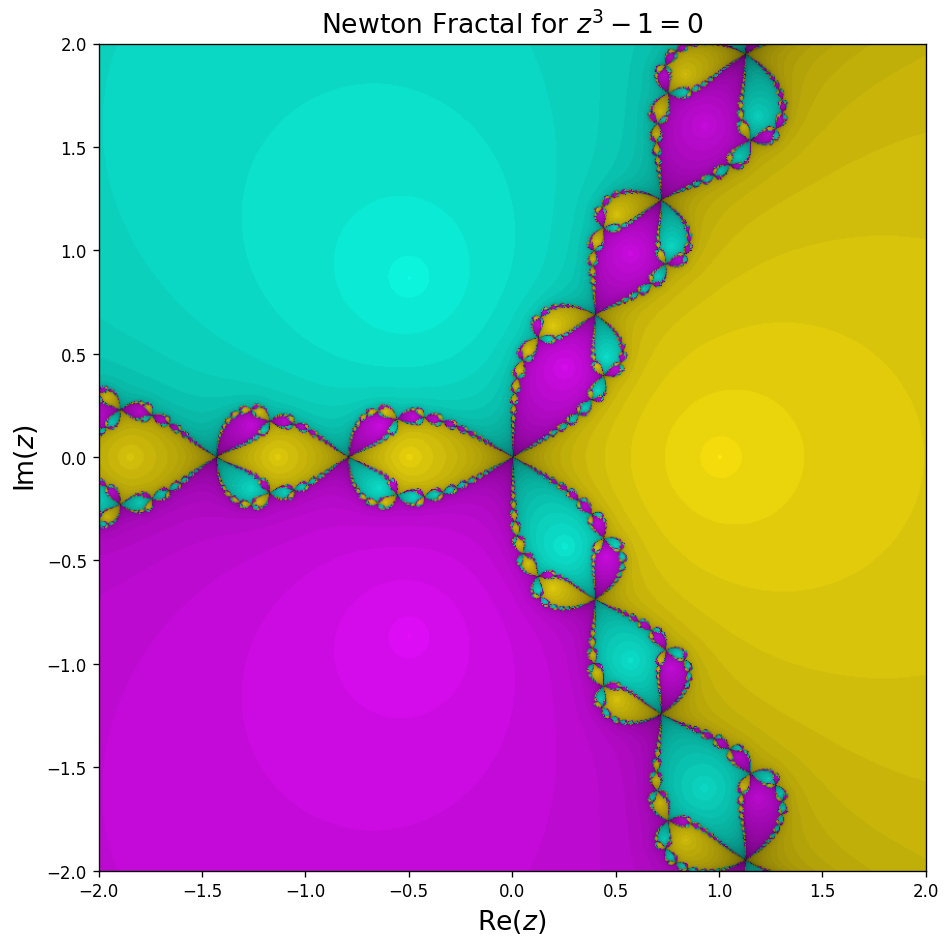

Generating Newton fractal for $z^4 - 1 = 0$...


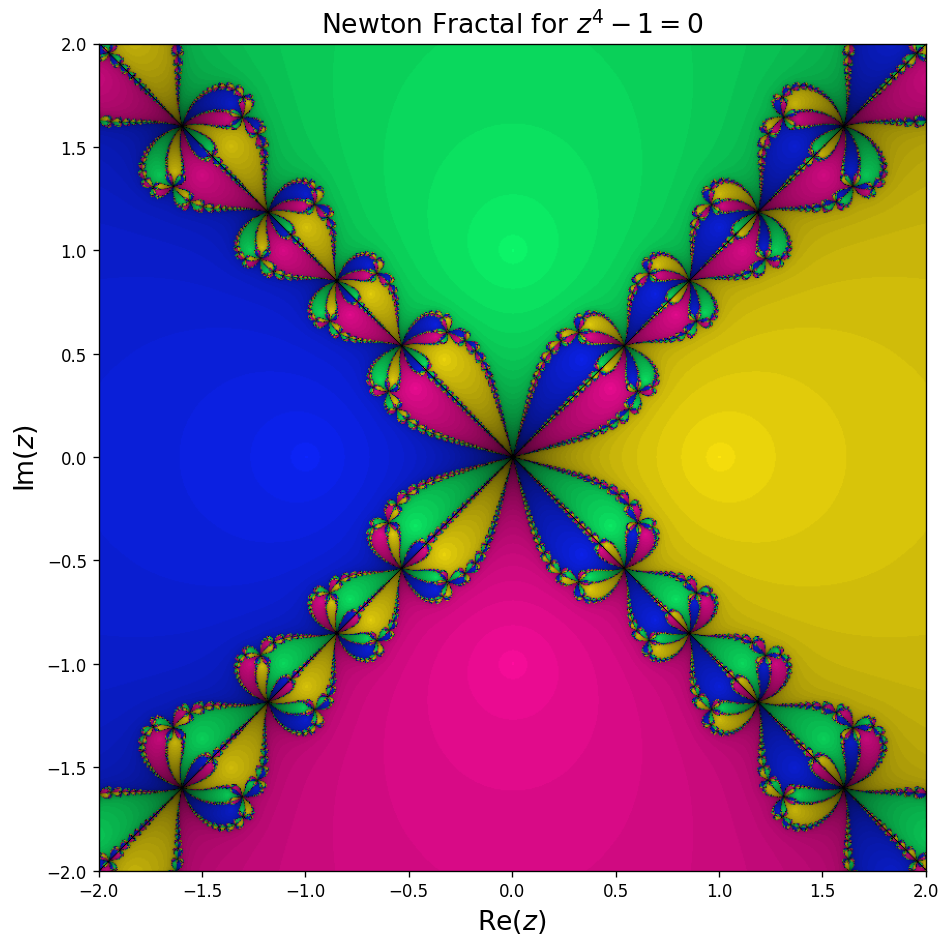

Generating Newton fractal for $z^5 - 1 = 0$...


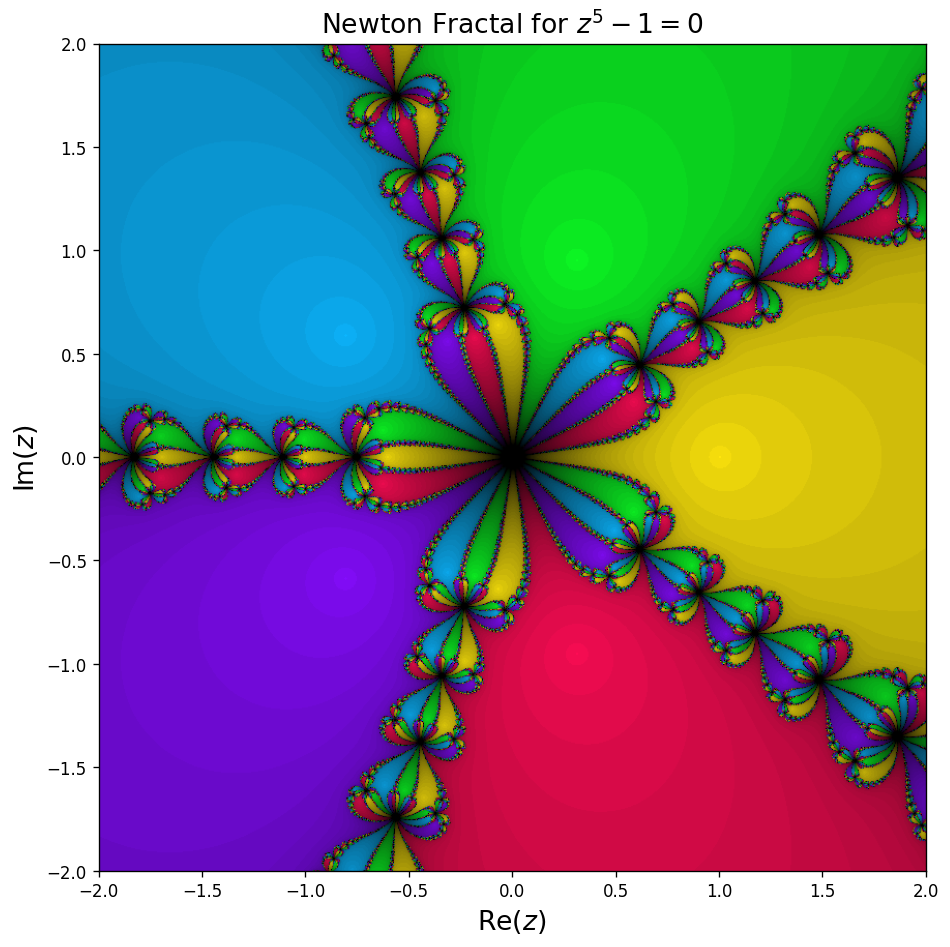

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from typing import Callable

# ==========================================
# 1. 方程式モジュール（対象データの仕様）
# ==========================================
class Equation:
    def __init__(self, f, df, roots):
        """方程式 f(z) = 0 を表すクラス．"""
        self.f  = f         # 関数 f(z)
        self.df = df        # 導関数 f'(z)
        self.roots = roots  # 複素方程式 f(z) = 0 の解析解の tuple

class UnityRootEquation(Equation):
    def __init__(self, n: int):
        """方程式 f(z) = z^n - 1 = 0 を定義するクラス．"""
        f  = lambda z: z**n - 1.0      # f(z) = z^n - 1
        df = lambda z: n * z**(n - 1)  # f'(z) = n * z^(n-1)
        roots = tuple(                 # n 乗根 exp(2πjk/n) (k=0,1,...,n-1)
            np.exp(2j * np.pi * k / n) for k in range(n)
        )

        super().__init__(f, df, roots)
        self.n = n
        self.name = f"$z^{n} - 1 = 0$"


# ==========================================
# 2. 数値計算モジュール（コアロジック 1/2）
# ==========================================
def solve_newton_grid(
    Z_init: np.ndarray,
    f: Callable[[np.ndarray], np.ndarray],
    df: Callable[[np.ndarray], np.ndarray],
    max_iter: int = 50,
    eps_z: float = 1e-8,   # convergence check for z update
    eps_f: float = 1e-8,   # convergence check for f(z)
    eps_df: float = 1e-12, # non-zero check for df
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    複素グリッド上でニュートン法を実行する．
    全ての点を同時に更新し，収束した点は以降の更新から除外する．

    戻り値:
        Z           : 各初期値から得られた最終的な近似解
        converged   : 収束したかどうか
        iter_count  : 収束までの反復回数．未収束なら max_iter
    """
    Z = Z_init         # overwrite in-place for memory efficiency
    Z_flat = Z.ravel() # get 1D view (not a copy) for easier indexing

    converged_flat = np.zeros(Z_flat.shape, dtype=bool)
    iter_count_flat = np.full(Z_flat.shape, max_iter, dtype=int)

    active_indices = np.arange(Z_flat.size)

    for i in range(max_iter):
        if active_indices.size == 0:
            break

        z = Z_flat[active_indices]  # fancy indexing なので z は専用コピー
        df_z = df(z)

        valid = np.abs(df_z) > eps_df

        # valid な点の上だけで補正量を求め，z を in-place で更新する
        z_valid = z[valid]
        inc = f(z_valid) / df_z[valid]
        z[valid] = z_valid - inc

        Z_flat[active_indices] = z

        # 収束し得るのは valid な点だけなので，そこだけ判定すればよい
        converged_now = np.zeros(z.shape, dtype=bool)
        converged_now[valid] = (np.abs(inc) < eps_z) & (np.abs(f(z[valid])) < eps_f)

        if np.any(converged_now):
            indices = active_indices[converged_now]
            converged_flat[indices] = True
            iter_count_flat[indices] = i + 1

        active_indices = active_indices[~converged_now]

    converged = converged_flat.reshape(Z.shape)
    iter_count = iter_count_flat.reshape(Z.shape)

    return Z, converged, iter_count


# ==========================================
# 3. 収束先分類モジュール（コアロジック 2/2）
# ==========================================
def classify_by_roots(
    Z: np.ndarray,
    roots: tuple[complex, ...],
    converged: np.ndarray,
    eps_z: float,
) -> np.ndarray:
    """
    近似解 Z を，最も近い既知の解 roots によって分類する．

    戻り値:
        root_index : 各点の収束先インデックス．分類しない点は -1．
    """
    root_index = np.full(Z.shape, -1, dtype=int)

    z = Z[converged]
    min_distance = np.full(z.shape, np.inf)
    nearest_root = np.full(z.shape, -1, dtype=int)

    for idx, root in enumerate(roots):
        distance = np.abs(z - root)
        closer = distance < min_distance
        min_distance[closer] = distance[closer]
        nearest_root[closer] = idx

    nearest_root[min_distance >= eps_z] = -1
    root_index[converged] = nearest_root
    return root_index


# ==========================================
# 4. 画像生成および描画モジュール（可視化）
# ==========================================
def generate_rgb_array(
    fractal_root: np.ndarray, 
    iter_count: np.ndarray, 
    num_roots: int, 
    max_iter: int,
    hue_offset: float = 0.15,  # 色相調整用 (0.0 ~ 1.0)
) -> np.ndarray:
    """
    計算結果の配列を HSV 色空間上で色付けして RGB 画像配列に変換する．
    収束の速さを明度 V，収束先の根のインデックスを色相 H で表現する．収束しなかった点は黒色になる．
    """
    H = np.zeros(fractal_root.shape)
    for idx in range(num_roots):
        H[fractal_root == idx] = (idx / num_roots + hue_offset) % 1.0
        
    S = np.ones(fractal_root.shape) * 0.95
    V = 1.0 - (iter_count / max_iter)**0.6
    V = V / V.max()  # 正規化して明度のコントラストを強調する
    
    # 収束しなかった点（インデックス -1）は明度を 0（黒）にする
    V[fractal_root == -1] = 0.0
    
    hsv_img = np.dstack((H, S, V))
    return hsv_to_rgb(hsv_img)

def plot_fractal_image(
    rgb_image: np.ndarray, 
    extent: tuple[float, float, float, float], 
    title: str,
) -> None:
    """RGB 配列を受け取り，Matplotlib で画面に描画する"""
    plt.figure(figsize=(8, 8), dpi=120, layout="tight")
    plt.imshow(rgb_image, extent=extent, origin='lower')
    plt.xlabel(r"$\mathrm{Re}(z)$", fontsize=16)
    plt.ylabel(r"$\mathrm{Im}(z)$", fontsize=16)
    plt.title(title, fontsize=16)
    plt.show()


# ==========================================
# 実行部
# ==========================================
def make_newton_fractal(equation: Equation, title: str):
    # グリッドの生成
    x0, x1, y0, y1 = -2.0, 2.0, -2.0, 2.0
    res_x, res_y = 800, 800
    x = np.linspace(x0, x1, res_x)
    y = np.linspace(y0, y1, res_y)
    X, Y = np.meshgrid(x, y)
    Z_init = X + 1j * Y

    # 複素ニュートン法の実行
    max_iterations = 50
    Z_final, converged, iter_count = solve_newton_grid(
        Z_init, equation.f, equation.df,
        max_iter=max_iterations, eps_z=1e-8, eps_f=1e-8
    )
    # 収束先の分類
    root_index = classify_by_roots(Z_final, equation.roots, converged=converged, eps_z=1e-5)

    # ニュートンフラクタルの描画
    rgb_image = generate_rgb_array(root_index, iter_count, len(equation.roots), max_iterations)
    plot_fractal_image(rgb_image, extent=(x0, x1, y0, y1), title=title)


for n in (3, 4, 5):
    equation = UnityRootEquation(n)
    title = f"Newton Fractal for {equation.name}"
    print(f"Generating Newton fractal for {equation.name}...")
    make_newton_fractal(equation, title=title)